# Stage 2: Out-of-Sample PCA Early Warning (Custom Split)

## Setup and Imports


In [1]:
#%pip install pandas pyarrow
import pandas as pd
import pyarrow.parquet as pq
import os

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


In [2]:
# load in all stablecoins
dai = pd.read_parquet("../clean_data/dai_clean.parquet")
pax = pd.read_parquet("../clean_data/pax_clean.parquet")
usdc = pd.read_parquet("../clean_data/usdc_clean.parquet")
usdt = pd.read_parquet("../clean_data/usdt_clean.parquet")
ust = pd.read_parquet("../clean_data/ust_clean.parquet")

In [3]:
print("DAI:", dai["depeg"].sum())
print("USDC:", usdc["depeg"].sum())
print("USDT:", usdt["depeg"].sum())
print("USDP:", pax["depeg"].sum())

ust_cut = ust[ust["timestamp"] <= "2022-05-11"]
print("ust:", ust_cut["depeg"].sum())

DAI: 32
USDC: 32
USDT: 29
USDP: 35
ust: 33


### Identifying Optimal Train/Test split
We define 2 functions below to help identify the optimal split for each stablecoin. 

* `split_equal_depegs`: the number of depegs in each split is approximately equal 

* `split_by_date`: split the data by a particular date

In [4]:

def split_equal_depegs(df, date_col="timestamp", target_col="depeg"):
    
    df = df.sort_values(date_col).reset_index(drop=True)
    df = df[df["timestamp"] <= "2024-12-31"]

    # cumulative number of depegs
    cumsum = df[target_col].cumsum()
    total = cumsum.iloc[-1]

    # find split where half depegs in each
    split_idx = (cumsum - total/2).abs().idxmin()

    train = df.iloc[:split_idx+1].copy()
    test  = df.iloc[split_idx+1:].copy()

    print("Split date:", df.loc[split_idx, date_col])
    print("Train depegs:", train[target_col].sum())
    print("Test  depegs:", test[target_col].sum())
    print("Train size:", len(train), "Test size:", len(test))
    print("------")

    return train, test


def split_by_date(df, split_date, date_col="timestamp"):
    df = df.sort_values(date_col).reset_index(drop=True)
    df = df[df[date_col] <= "2024-12-31"]
    train = df[df[date_col] <= split_date].copy()
    test  = df[df[date_col] >  split_date].copy()
    print(f"Split date: {split_date}")
    print(f"Train depegs: {train['depeg'].sum()}, Test depegs: {test['depeg'].sum()}")
    print(f"Train size: {len(train)}, Test size: {len(test)}")
    print("------")
    return train, test

In [5]:
MANUAL_SPLITS = {
    "USDC": "2022-06-30",
    "USDT": "2022-06-30",
    "DAI":  "2022-06-30",
}

splits = {}

for name, df in {"DAI": dai, "USDC": usdc, "USDT": usdt, "USDP": pax}.items():
    print(name)
    if name in MANUAL_SPLITS:
        train, test = split_by_date(df, MANUAL_SPLITS[name])
    else:
        train, test = split_equal_depegs(df)
    splits[name] = (train, test)

# TerraUSD (only using period up till May 2022)
print("UST (TerraUSD)")
ust_cut = ust[ust["timestamp"] <= "2022-05-11"]
ust_train, ust_test = split_by_date(ust_cut, "2021-10-01")

splits["UST (TerraUSD)"] = (ust_train, ust_test)

DAI
Split date: 2022-06-30
Train depegs: 30, Test depegs: 2
Train size: 582, Test size: 915
------
USDC
Split date: 2022-06-30
Train depegs: 27, Test depegs: 5
Train size: 582, Test size: 915
------
USDT
Split date: 2022-06-30
Train depegs: 13, Test depegs: 14
Train size: 582, Test size: 915
------
USDP
Split date: 2023-07-25 23:59:59
Train depegs: 17
Test  depegs: 18
Train size: 973 Test size: 524
------
UST (TerraUSD)
Split date: 2021-10-01
Train depegs: 25, Test depegs: 8
Train size: 310, Test size: 222
------


### Summary Table

In [6]:
summary = []

for k,(tr,te) in splits.items():
    summary.append({
        "coin": k,
        "train_start": tr.timestamp.min(),
        "train_end": tr.timestamp.max(),
        "test_start": te.timestamp.min(),
        "test_end": te.timestamp.max(),
        "train_depegs": tr.depeg.sum(),
        "test_depegs": te.depeg.sum()
    })

pd.DataFrame(summary)

,coin,train_start,train_end,test_start,test_end,train_depegs,test_depegs
0,DAI,2020-11-25 23:59:59,2022-06-29 23:59:59,2022-06-30 23:59:59,2024-12-30 23:59:59,30,2
1,USDC,2020-11-25 23:59:59,2022-06-29 23:59:59,2022-06-30 23:59:59,2024-12-30 23:59:59,27,5
2,USDT,2020-11-25 23:59:59,2022-06-29 23:59:59,2022-06-30 23:59:59,2024-12-30 23:59:59,13,14
3,USDP,2020-11-25 23:59:59,2023-07-25 23:59:59,2023-07-26 23:59:59,2024-12-30 23:59:59,17,18
4,UST (TerraUSD),2020-11-25 23:59:59,2021-09-30 23:59:59,2021-10-01 23:59:59,2022-05-10 23:59:59,25,8


## PCA Framework

In [7]:
df_dai_final = pd.read_parquet("../clean_data/dai_final.parquet")
df_pax_final = pd.read_parquet("../clean_data/pax_final.parquet")
df_usdc_final = pd.read_parquet("../clean_data/usdc_final.parquet")
df_usdt_final = pd.read_parquet("../clean_data/usdt_final.parquet")
df_ust_final = pd.read_parquet("../clean_data/ust_final.parquet")
# only use ust data up till May 2022
df_ust_final = df_ust_final[df_ust_final["timestamp"] <= "2022-05-11"]

In [8]:
# Prepare PCA input
def prepare_stablecoin_pca_df(df):

    drop_cols = [
        'depeg', 'timeOpen', 'timeClose', 'timeHigh', 'timeLow',
        'open', 'high', 'low', 'close', 'volume', 'marketCap', 'circulatingSupply',
        'depeg_future_1d', 'depeg_future_3d', 'depeg_future_5d', 'depeg_future_7d', 
        'depeg_future_14d', 'depeg_future_30d'
    ]

    pca_df = df.copy()

    # Drop only columns that actually exist
    pca_df = pca_df.drop(columns=[c for c in drop_cols if c in pca_df.columns], errors="ignore")
    
    pca_df['timestamp'] = pd.to_datetime(pca_df['timestamp']).dt.normalize()
    # Keep only timestamp, symbol and numeric feature columns
    pca_df = pca_df[['timestamp', 'symbol'] + [c for c in pca_df.columns if c not in ['timestamp', 'symbol'] and pd.api.types.is_numeric_dtype(pca_df[c])]]

    # Sort by time
    pca_df = pca_df.sort_values('timestamp').reset_index(drop=True)
    
    return pca_df

### Split Each Stablecoin into Train/Test

In [9]:
dai_train, dai_test = split_by_date(df_dai_final,  MANUAL_SPLITS["DAI"])
dai_train_pca = prepare_stablecoin_pca_df(dai_train)
dai_test_pca = prepare_stablecoin_pca_df(dai_test)

pax_train, pax_test = split_equal_depegs(df_pax_final)
pax_train_pca = prepare_stablecoin_pca_df(pax_train)
pax_test_pca = prepare_stablecoin_pca_df(pax_test)

usdc_train, usdc_test = split_by_date(df_usdc_final, MANUAL_SPLITS["USDC"])
usdc_train_pca = prepare_stablecoin_pca_df(usdc_train)
usdc_test_pca = prepare_stablecoin_pca_df(usdc_test)

usdt_train, usdt_test = split_by_date(df_usdt_final, MANUAL_SPLITS["USDT"])
usdt_train_pca = prepare_stablecoin_pca_df(usdt_train)
usdt_test_pca = prepare_stablecoin_pca_df(usdt_test)

ust_train, ust_test = split_by_date(df_ust_final, "2021-10-01")
ust_train_pca = prepare_stablecoin_pca_df(ust_train)
ust_test_pca = prepare_stablecoin_pca_df(ust_test)


Split date: 2022-06-30
Train depegs: 21, Test depegs: 2
Train size: 552, Test size: 915
------
Split date: 2023-07-25 23:59:59
Train depegs: 17
Test  depegs: 18
Train size: 943 Test size: 524
------
Split date: 2022-06-30
Train depegs: 27, Test depegs: 5
Train size: 552, Test size: 915
------
Split date: 2022-06-30
Train depegs: 12, Test depegs: 14
Train size: 552, Test size: 915
------
Split date: 2021-10-01
Train depegs: 25, Test depegs: 8
Train size: 280, Test size: 222
------


Note that the number of depegs changes here is because {coin}_final.parquet was used instead of {coin}_clean.parquet. 

{coin}_final.parquet includes a column 'depeg_future_30d', so the start of this dataset is a month later than {coin}_clean.parquet, causing the depegs in the first month to be cut off.

### Run PCA

In [10]:
# Function to run PCA
def fit_fixed_pca(train_df, test_df, n_components):
    numeric_cols = [c for c in train_df.columns if c not in ["timestamp", "symbol"]]

    # Imputer: fill NaNs with training mean
    imputer = SimpleImputer(strategy="mean")
    X_train_imputed = imputer.fit_transform(train_df[numeric_cols])

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imputed)
    
    pca = PCA(n_components=n_components)
    X_train_pcs = pca.fit_transform(X_train_scaled)
    
    # Train results
    train_pcs = pd.DataFrame(X_train_pcs, columns=[f"PC{i+1}" for i in range(X_train_pcs.shape[1])], index=train_df.index)
    
    # Test projection
    X_test_imputed = imputer.transform(test_df[numeric_cols])
    X_test_scaled = scaler.transform(X_test_imputed)
    test_pcs = pd.DataFrame(pca.transform(X_test_scaled), columns=train_pcs.columns, index=test_df.index)
    
    return {
        "loadings": pd.DataFrame(pca.components_.T, index=numeric_cols),
        "explained_variance": pca.explained_variance_ratio_,
        "pc_scores_train": train_pcs,
        "pc_scores_test": test_pcs
    }

In [11]:
# DAI
dai_pca_result = fit_fixed_pca(dai_train_pca, dai_test_pca, n_components=10)

# USDC
usdc_pca_result = fit_fixed_pca(usdc_train_pca, usdc_test_pca, n_components=10)

# UST
ust_pca_result = fit_fixed_pca(ust_train_pca, ust_test_pca, n_components=10)

# USDT
usdt_pca_result = fit_fixed_pca(usdt_train_pca, usdt_test_pca, n_components=10)

# USDP (PAX)
pax_pca_result = fit_fixed_pca(pax_train_pca, pax_test_pca, n_components=10)

In [12]:
os.makedirs("customsplit", exist_ok=True)

for coin, res in [
    ("UST", ust_pca_result),
    ("USDC", usdc_pca_result),
    ("DAI", dai_pca_result),
    ("USDT", usdt_pca_result),
    ("USDP", pax_pca_result),
]:
    base = f"customsplit/{coin}"
    
    # 1. loadings (DataFrame → CSV)
    res["loadings"].to_csv(f"{base}_loadings.csv")
    
    # 2. explained variance (array → CSV)
    pd.DataFrame(res["explained_variance"]).to_csv(f"{base}_explained_variance.csv", index=False)
    
    # 3. PC scores (arrays → CSV)
    pd.DataFrame(res["pc_scores_train"]).to_csv(f"{base}_pc_train.csv", index=False)
    pd.DataFrame(res["pc_scores_test"]).to_csv(f"{base}_pc_test.csv", index=False)

## Analysis

In [13]:

# We first look at all 10 PCs 
 
PC_SELECTIONS = {
    "UST":  [0,1,2,3,4,5,6,7,8,9],   
    "USDC": [1,2,9,0,3,4,5,6,7,8],      
    "DAI":  [0,2,7,1,3,4,5,6,8,9],   
    "USDT": [2,3,6,0,1,4,5,7,8,9],      
    "USDP": [0,1,2,3,4,5,6,7,8,9],      
}

def compute_training_benchmark(pca_result, selected_pcs):
    train_scores = pca_result["pc_scores_train"]
    pc_cols = [f"PC{i+1}" for i in selected_pcs]
    mu    = train_scores[pc_cols].mean()
    sigma = train_scores[pc_cols].std(ddof=1)
    print("Training benchmark distribution:")
    for col in pc_cols:
        print(f"  {col}: mean={mu[col]:.4f}, sd={sigma[col]:.4f}")
    return {"mu": mu, "sigma": sigma, "pc_cols": pc_cols}



In [14]:

# test z-scores and anomaly signal

def compute_test_zscores(pca_result, benchmark):
    test_scores = pca_result["pc_scores_test"][benchmark["pc_cols"]]
    z_scores = (test_scores - benchmark["mu"]) / benchmark["sigma"]
    z_scores.columns = [f"z_{c}" for c in benchmark["pc_cols"]]
    return z_scores


def generate_signal(z_scores, threshold=3.0, consecutive_days=1):
    #Binary signal: 1 if ANY monitored PC exceeds ±threshold.
    #consecutive_days > 1 requires that many consecutive triggers (noise filter).
    any_exceed = (z_scores.abs() > threshold).any(axis=1).astype(int)
    if consecutive_days <= 1:
        return any_exceed
    rolling_sum = any_exceed.rolling(window=consecutive_days, min_periods=consecutive_days).sum()
    return (rolling_sum >= consecutive_days).astype(int)



In [15]:

# warning labels

def build_warning_labels(test_df, signal, window_days=7,
                         date_col="timestamp", depeg_col="depeg"):
    #Label each test day 1 if it falls within `window_days` before a depeg
    #excluding of the depeg day itself)
    
    df = test_df[[date_col, depeg_col]].copy().reset_index(drop=True)
    df["date"]   = pd.to_datetime(df[date_col]).dt.normalize()
    df["signal"] = signal.values
    df["depeg"]  = df[depeg_col].values

    depeg_dates = df.loc[df["depeg"] == 1, "date"].values

    def min_lead(d):
        future = depeg_dates[depeg_dates >= d]
        return (future[0] - d) / np.timedelta64(1, "D") if len(future) > 0 else np.nan

    df["lead_days"] = df["date"].apply(min_lead)
    df["label"]     = ((df["lead_days"] > 0) & (df["lead_days"] <= window_days)).astype(int)
    return df[["date", "signal", "depeg", "label", "lead_days"]]



In [16]:

# predictive metrics

def compute_metrics(labeled_df, coin=""):
    y_true = labeled_df["label"].values
    y_pred = labeled_df["signal"].values

    TP = int(((y_pred == 1) & (y_true == 1)).sum())
    FP = int(((y_pred == 1) & (y_true == 0)).sum())
    TN = int(((y_pred == 0) & (y_true == 0)).sum())
    FN = int(((y_pred == 0) & (y_true == 1)).sum())

    precision   = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    recall      = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    f1          = (2 * precision * recall / (precision + recall)
                   if not (np.isnan(precision) or np.isnan(recall) or (precision + recall) == 0)
                   else np.nan)
    specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan

    tp_mask      = (y_pred == 1) & (y_true == 1)
    avg_lead     = labeled_df.loc[tp_mask, "lead_days"].dropna().mean()
    fa_per_month = FP / (len(labeled_df) / 30.44)

    print(f"\n{'='*50}")
    print(f"  {coin} — Predictive Metrics")
    print(f"{'='*50}")
    print(f"  Confusion: TP={TP}, FP={FP}, TN={TN}, FN={FN}")
    print(f"  Precision  (key): {precision:.3f}")
    print(f"  Recall:           {recall:.3f}")
    print(f"  F1:               {f1:.3f}")
    print(f"  Specificity:      {specificity:.3f}")
    print(f"  Avg lead time:    {avg_lead:.1f} days before depeg")
    print(f"  False alarms:     {fa_per_month:.2f} / month")

    return {
        "coin": coin,
        "TP": TP, "FP": FP, "TN": TN, "FN": FN,
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "specificity": round(specificity, 4),
        "avg_lead_days": round(avg_lead, 2) if not np.isnan(avg_lead) else np.nan,
        "fa_per_month": round(fa_per_month, 2),
        "n_test_days": len(labeled_df),
    }



In [17]:
def run_oos_evaluation(coin, pca_result, test_df, selected_pcs=None,
                       threshold=3.0, consecutive_days=1, window_days=7):
    if selected_pcs is None:
        selected_pcs = PC_SELECTIONS.get(coin, [0])

    # Combined signal across all selected PCs
    benchmark  = compute_training_benchmark(pca_result, selected_pcs)
    z_scores   = compute_test_zscores(pca_result, benchmark)
    signal     = generate_signal(z_scores, threshold=threshold, consecutive_days=consecutive_days)
    labeled_df = build_warning_labels(test_df, signal, window_days=window_days)
    metrics    = compute_metrics(labeled_df, coin=coin)

    # Per-PC breakdown
    pc_rows = []
    for pc_idx in selected_pcs:
        bm   = compute_training_benchmark(pca_result, [pc_idx])
        z    = compute_test_zscores(pca_result, bm)
        sig  = generate_signal(z, threshold=threshold, consecutive_days=consecutive_days)
        ldf  = build_warning_labels(test_df, sig, window_days=window_days)
        m    = compute_metrics(ldf, coin=f"{coin} PC{pc_idx+1}")
        m["pc"] = f"PC{pc_idx+1}"
        pc_rows.append(m)
    pc_breakdown = pd.DataFrame(pc_rows)[["pc","precision","recall","f1","specificity","avg_lead_days","fa_per_month","TP","FP","TN","FN"]]

    return {"metrics": metrics, "labeled_df": labeled_df,
            "z_scores": z_scores, "benchmark": benchmark, "signal": signal,
            "pc_breakdown": pc_breakdown}


def sensitivity_sweep(coin, pca_result, test_df, selected_pcs,
                      thresholds=[1.5, 2.0, 2.5, 3.0],
                      windows=[5, 7, 10], consecutive_days=1):
    rows = []
    for thr in thresholds:
        for win in windows:
            bm  = compute_training_benchmark(pca_result, selected_pcs)
            z   = compute_test_zscores(pca_result, bm)
            sig = generate_signal(z, threshold=thr, consecutive_days=consecutive_days)
            ldf = build_warning_labels(test_df, sig, window_days=win)
            m   = compute_metrics(ldf, coin=coin)
            m["threshold"] = thr; m["window"] = win
            rows.append(m)
    cols = ["coin","threshold","window","precision","recall","f1",
            "specificity","avg_lead_days","fa_per_month","TP","FP","TN","FN"]
    return pd.DataFrame(rows)[cols].sort_values(["precision","recall"], ascending=False)

In [18]:

# Plot: z-score timeline with depeg markers and warning windows

def plot_signal_timeline(result, coin, threshold=3.0, figsize=(14, 4)):
    labeled_df = result["labeled_df"]
    z_scores   = result["z_scores"]
    dates      = labeled_df["date"].values

    fig, axes = plt.subplots(len(z_scores.columns), 1, figsize=figsize, sharex=True)
    if len(z_scores.columns) == 1:
        axes = [axes]

    #add signals
    signal_dates = labeled_df.loc[labeled_df["signal"] == 1, "date"].values

    for ax, col in zip(axes, z_scores.columns):
        ax.plot(dates, z_scores[col].values, lw=1.2, color="steelblue", label=col)
        ax.axhline( threshold, color="darkorange", ls="--", lw=1, label=f"+{threshold}σ")
        ax.axhline(-threshold, color="darkorange", ls="--", lw=1)

        # shade pre-depeg warning windows
        in_window = labeled_df["label"].values == 1
        starts = np.where(np.diff(np.concatenate([[0], in_window.astype(int), [0]])) == 1)[0]
        ends   = np.where(np.diff(np.concatenate([[0], in_window.astype(int), [0]])) == -1)[0]
        for s, e in zip(starts, ends):
            ax.axvspan(dates[s], dates[min(e, len(dates)-1)], alpha=0.12, color="salmon")

        # depeg day markers
        for dd in labeled_df.loc[labeled_df["depeg"] == 1, "date"].values:
            ax.axvline(dd, color="crimson", lw=1.5, alpha=0.85)

        # signal markers
        for sd in signal_dates:
            ax.axvline(sd, color="royalblue", lw=1, alpha=0.25)

        ax.set_ylabel(col, fontsize=9)
        ax.legend(loc="upper left", fontsize=8)
        ax.grid(True, alpha=0.25)

    axes[-1].set_xlabel("Date")
    fig.suptitle(f"{coin} — OOS Signal (crimson=depeg, shading=warning window)",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()



### Usage

In [19]:
# Execution
# Run all coins 
results = {}
for coin, pca_res, test in [
    ("UST",  ust_pca_result,  ust_test),
    ("USDC", usdc_pca_result, usdc_test),
    ("DAI",  dai_pca_result,  dai_test),
    ("USDT", usdt_pca_result, usdt_test),
    ("USDP", pax_pca_result,  pax_test),
]:
    results[coin] = run_oos_evaluation(coin, pca_res, test, threshold=3.0, window_days=7)

# Sensitivity sweep for UST
#ust_sweep = sensitivity_sweep("UST", ust_pca_result, ust_test, PC_SELECTIONS["UST"])
#display(ust_sweep.head(12))


Training benchmark distribution:
  PC1: mean=-0.0000, sd=2.3990
  PC2: mean=-0.0000, sd=2.0574
  PC3: mean=-0.0000, sd=1.6072
  PC4: mean=0.0000, sd=1.2722
  PC5: mean=0.0000, sd=1.1699
  PC6: mean=0.0000, sd=1.0749
  PC7: mean=-0.0000, sd=1.0352
  PC8: mean=0.0000, sd=0.9953
  PC9: mean=0.0000, sd=0.8146
  PC10: mean=0.0000, sd=0.7314

  UST — Predictive Metrics
  Confusion: TP=9, FP=54, TN=133, FN=26
  Precision  (key): 0.143
  Recall:           0.257
  F1:               0.184
  Specificity:      0.711
  Avg lead time:    3.7 days before depeg
  False alarms:     7.40 / month
Training benchmark distribution:
  PC1: mean=-0.0000, sd=2.3990

  UST PC1 — Predictive Metrics
  Confusion: TP=0, FP=1, TN=186, FN=35
  Precision  (key): 0.000
  Recall:           0.000
  F1:               nan
  Specificity:      0.995
  Avg lead time:    nan days before depeg
  False alarms:     0.14 / month
Training benchmark distribution:
  PC2: mean=0.0000, sd=2.0574

  UST PC2 — Predictive Metrics
  Confus

In [20]:
# Combined summary table (one row per coin)
print("\n=== Combined signal (all selected PCs) ===")
display(pd.DataFrame([r["metrics"] for r in results.values()]).set_index("coin"))

# Per-PC breakdown (one row per PC per coin)
print("\n=== Per-PC breakdown ===")
for coin, res in results.items():
    print(f"\n{coin}")
    display(res["pc_breakdown"].set_index("pc"))


=== Combined signal (all selected PCs) ===


,TP,FP,TN,FN,precision,recall,f1,specificity,avg_lead_days,fa_per_month,n_test_days
coin,,,,,,,,,,,
UST,9,54,133,26,0.1429,0.2571,0.1837,0.7112,3.67,7.40,222
USDC,13,839,63,0,0.0153,1.0000,0.0301,0.0698,3.77,27.91,915
DAI,7,884,24,0,0.0079,1.0000,0.0156,0.0264,4.00,29.41,915
USDT,28,849,38,0,0.0319,1.0000,0.0619,0.0428,4.00,28.24,915
USDP,8,64,381,71,0.1111,0.1013,0.1060,0.8562,3.88,3.72,524



=== Per-PC breakdown ===

UST


,precision,recall,f1,specificity,avg_lead_days,fa_per_month,TP,FP,TN,FN
pc,,,,,,,,,,
PC1,0.0000,0.0000,NaN,0.9947,NaN,0.14,0,1,186,35
PC2,0.0000,0.0000,NaN,0.9893,NaN,0.27,0,2,185,35
PC3,0.6667,0.1143,0.1951,0.9893,2.50,0.27,4,2,185,31
PC4,0.5714,0.1143,0.1905,0.9840,2.50,0.41,4,3,184,31
PC5,0.3846,0.1429,0.2083,0.9572,2.60,1.10,5,8,179,30
PC6,0.6667,0.1143,0.1951,0.9893,2.50,0.27,4,2,185,31
PC7,0.1273,0.2000,0.1556,0.7433,4.00,6.58,7,48,139,28
PC8,0.1429,0.2286,0.1758,0.7433,3.75,6.58,8,48,139,27
PC9,0.4000,0.1143,0.1778,0.9679,2.50,0.82,4,6,181,31



USDC


...

,precision,recall,f1,specificity,avg_lead_days,fa_per_month,TP,FP,TN,FN
pc,,,,,,,,,,
PC1,0.0000,0.0000,NaN,0.9901,NaN,0.30,0,9,899,7
PC3,0.0000,0.0000,NaN,0.9868,NaN,0.40,0,12,896,7
PC8,0.0082,1.0000,0.0162,0.0661,4.0,28.21,7,848,60,0
PC2,0.0000,0.0000,NaN,0.9956,NaN,0.13,0,4,904,7
PC4,0.0000,0.0000,NaN,0.9879,NaN,0.37,0,11,897,7
PC5,0.0078,0.7143,0.0154,0.2996,3.6,21.16,5,636,272,2
PC6,0.0000,0.0000,NaN,0.9978,NaN,0.07,0,2,906,7
PC7,0.0091,1.0000,0.0180,0.1586,4.0,25.42,7,764,144,0
PC9,0.0080,1.0000,0.0159,0.0474,4.0,28.78,7,865,43,0



USDT


,precision,recall,f1,specificity,avg_lead_days,fa_per_month,TP,FP,TN,FN
pc,,,,,,,,,,
PC3,0.0437,0.2500,0.0745,0.8275,2.86,5.09,7,153,734,21
PC4,0.1667,0.1429,0.1538,0.9775,3.00,0.67,4,20,867,24
PC7,0.1667,0.1071,0.1304,0.9831,3.33,0.50,3,15,872,25
PC1,0.0000,0.0000,NaN,0.9977,NaN,0.07,0,2,885,28
PC2,0.0000,0.0000,NaN,0.9865,NaN,0.40,0,12,875,28
PC5,0.0314,0.8214,0.0605,0.2007,3.96,23.59,23,709,178,5
PC6,0.0000,0.0000,NaN,0.9932,NaN,0.20,0,6,881,28
PC8,0.2308,0.1071,0.1463,0.9887,2.67,0.33,3,10,877,25
PC9,0.0000,0.0000,NaN,0.9696,NaN,0.90,0,27,860,28



USDP


,precision,recall,f1,specificity,avg_lead_days,fa_per_month,TP,FP,TN,FN
pc,,,,,,,,,,
PC1,0.1364,0.0380,0.0594,0.9573,2.67,1.10,3,19,426,76
PC2,0.0000,0.0000,NaN,0.9933,NaN,0.17,0,3,442,79
PC3,0.2222,0.0253,0.0455,0.9843,2.00,0.41,2,7,438,77
PC4,0.0000,0.0000,NaN,0.9978,NaN,0.06,0,1,444,79
PC5,0.0000,0.0000,NaN,0.9978,NaN,0.06,0,1,444,79
PC6,0.0000,0.0000,NaN,0.9955,NaN,0.12,0,2,443,79
PC7,0.0000,0.0000,NaN,0.9888,NaN,0.29,0,5,440,79
PC8,0.0000,0.0000,NaN,0.9528,NaN,1.22,0,21,424,79
PC9,0.2308,0.0380,0.0652,0.9775,6.33,0.58,3,10,435,76


In [21]:
# Re-selecting the PCs based on the best performing ones (F1-score)
PC_SELECTIONS = {
    "UST":  [3,5,9],      #PC 4,6,10
    "USDC": [0,4,5],      #PC 1,5,6
    "DAI":  [7,6,9],      #PC 7,8,10
    "USDT": [3,6,7],      #PC 4,7,8
    "USDP": [0,2,8],      #PC 1,3,9
}

In [22]:
results = {}
for coin, pca_res, test in [
    ("UST",  ust_pca_result,  ust_test),
    ("USDC", usdc_pca_result, usdc_test),
    ("DAI",  dai_pca_result,  dai_test),
    ("USDT", usdt_pca_result, usdt_test),
    ("USDP", pax_pca_result,  pax_test),
]:
    results[coin] = run_oos_evaluation(coin, pca_res, test, threshold=3.0, window_days=7)

# Combined summary table (one row per coin)
print("\n=== Combined signal (all selected PCs) ===")
display(pd.DataFrame([r["metrics"] for r in results.values()]).set_index("coin"))

# Per-PC breakdown (one row per PC per coin)
print("\n=== Per-PC breakdown ===")
for coin, res in results.items():
    print(f"\n{coin}")
    display(res["pc_breakdown"].set_index("pc"))

Training benchmark distribution:
  PC4: mean=0.0000, sd=1.2722
  PC6: mean=0.0000, sd=1.0749
  PC10: mean=0.0000, sd=0.7314

  UST — Predictive Metrics
  Confusion: TP=5, FP=3, TN=184, FN=30
  Precision  (key): 0.625
  Recall:           0.143
  F1:               0.233
  Specificity:      0.984
  Avg lead time:    2.6 days before depeg
  False alarms:     0.41 / month
Training benchmark distribution:
  PC4: mean=-0.0000, sd=1.2722

  UST PC4 — Predictive Metrics
  Confusion: TP=4, FP=3, TN=184, FN=31
  Precision  (key): 0.571
  Recall:           0.114
  F1:               0.190
  Specificity:      0.984
  Avg lead time:    2.5 days before depeg
  False alarms:     0.41 / month
Training benchmark distribution:
  PC6: mean=0.0000, sd=1.0749

  UST PC6 — Predictive Metrics
  Confusion: TP=4, FP=2, TN=185, FN=31
  Precision  (key): 0.667
  Recall:           0.114
  F1:               0.195
  Specificity:      0.989
  Avg lead time:    2.5 days before depeg
  False alarms:     0.27 / month
Tra

,TP,FP,TN,FN,precision,recall,f1,specificity,avg_lead_days,fa_per_month,n_test_days
coin,,,,,,,,,,,
UST,5,3,184,30,0.6250,0.1429,0.2326,0.9840,2.60,0.41,222
USDC,6,36,866,7,0.1429,0.4615,0.2182,0.9601,3.50,1.20,915
DAI,7,867,41,0,0.0080,1.0000,0.0159,0.0452,4.00,28.84,915
USDT,5,32,855,23,0.1351,0.1786,0.1538,0.9639,2.80,1.06,915
USDP,8,34,411,71,0.1905,0.1013,0.1322,0.9236,3.88,1.98,524



=== Per-PC breakdown ===

UST


,precision,recall,f1,specificity,avg_lead_days,fa_per_month,TP,FP,TN,FN
pc,,,,,,,,,,
PC4,0.5714,0.1143,0.1905,0.9840,2.5,0.41,4,3,184,31
PC6,0.6667,0.1143,0.1951,0.9893,2.5,0.27,4,2,185,31
PC10,0.7143,0.1429,0.2381,0.9893,2.6,0.27,5,2,185,30



USDC


...

,precision,recall,f1,specificity,avg_lead_days,fa_per_month,TP,FP,TN,FN
pc,,,,,,,,,,
PC8,0.0082,1.0,0.0162,0.0661,4.0,28.21,7,848,60,0
PC7,0.0091,1.0,0.0180,0.1586,4.0,25.42,7,764,144,0
PC10,0.0081,1.0,0.0160,0.0540,4.0,28.58,7,859,49,0



USDT


,precision,recall,f1,specificity,avg_lead_days,fa_per_month,TP,FP,TN,FN
pc,,,,,,,,,,
PC4,0.1667,0.1429,0.1538,0.9775,3.00,0.67,4,20,867,24
PC7,0.1667,0.1071,0.1304,0.9831,3.33,0.50,3,15,872,25
PC8,0.2308,0.1071,0.1463,0.9887,2.67,0.33,3,10,877,25



USDP


,precision,recall,f1,specificity,avg_lead_days,fa_per_month,TP,FP,TN,FN
pc,,,,,,,,,,
PC1,0.1364,0.0380,0.0594,0.9573,2.67,1.10,3,19,426,76
PC3,0.2222,0.0253,0.0455,0.9843,2.00,0.41,2,7,438,77
PC9,0.2308,0.0380,0.0652,0.9775,6.33,0.58,3,10,435,76


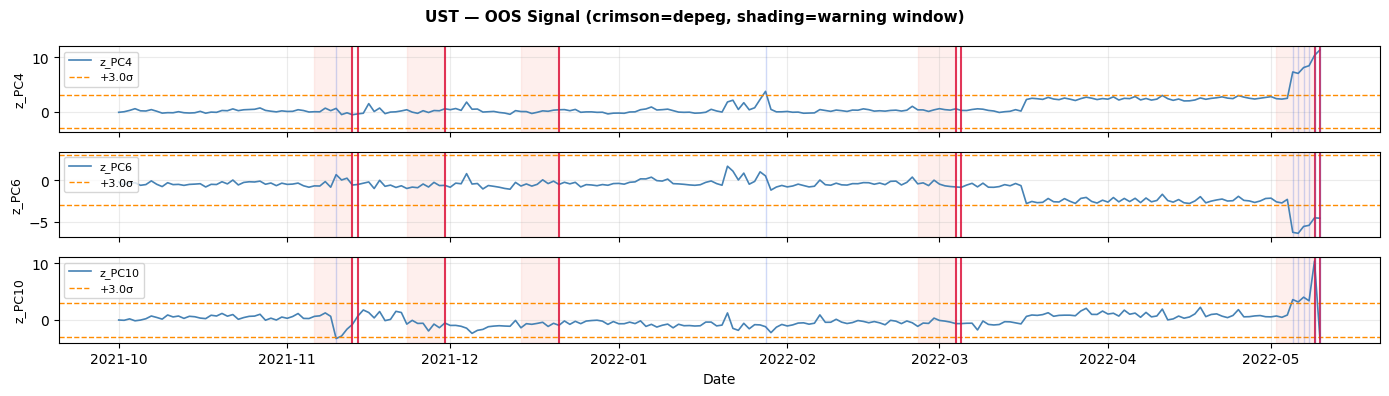

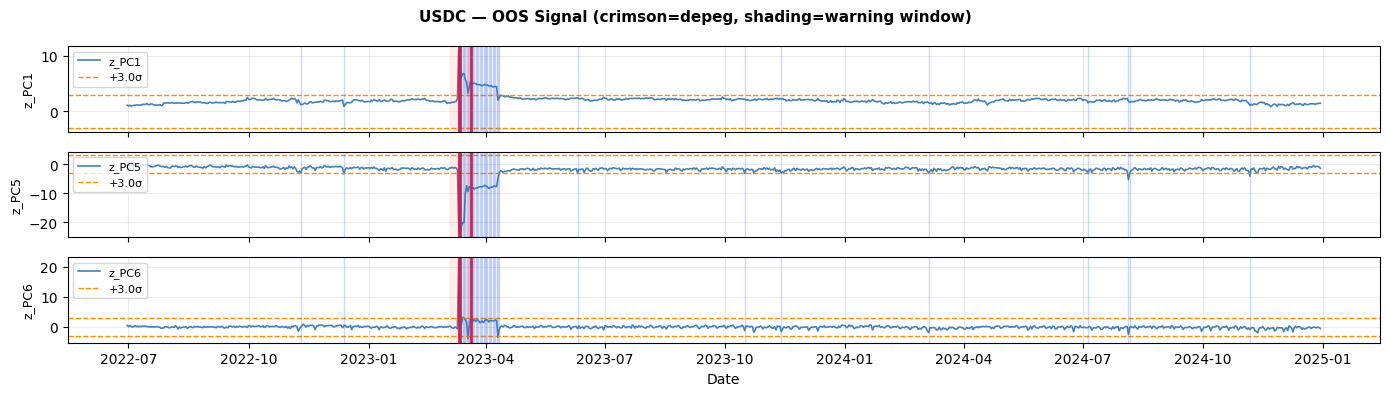

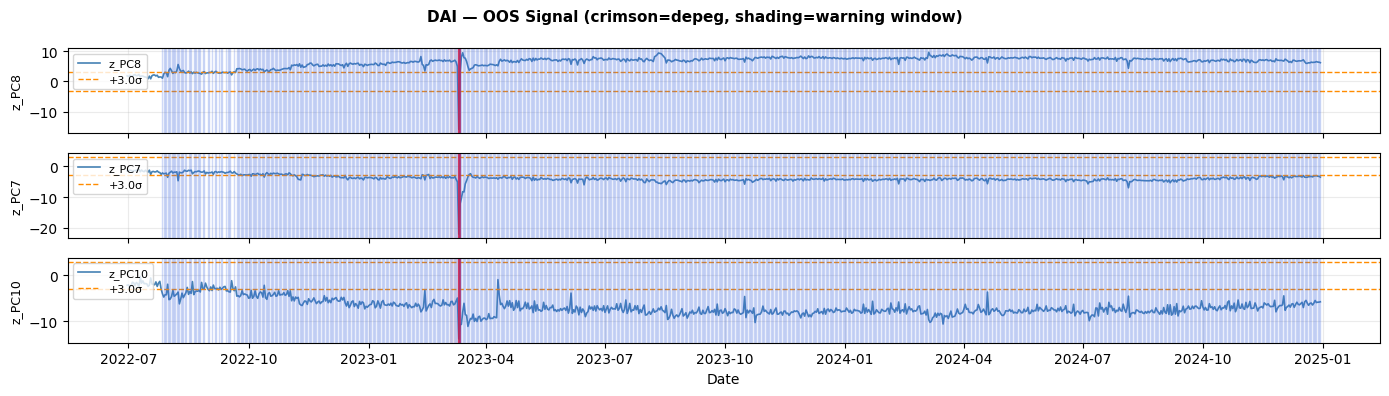

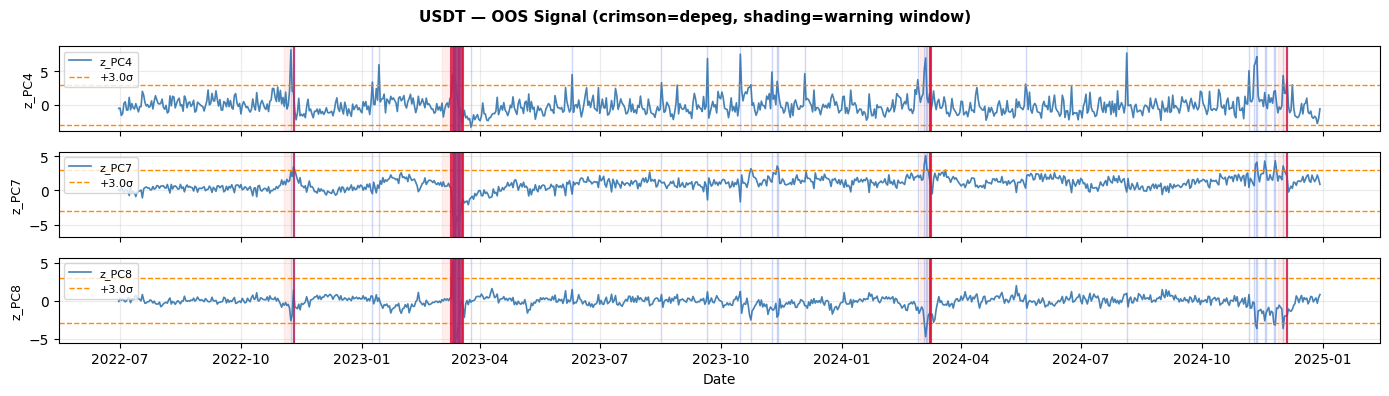

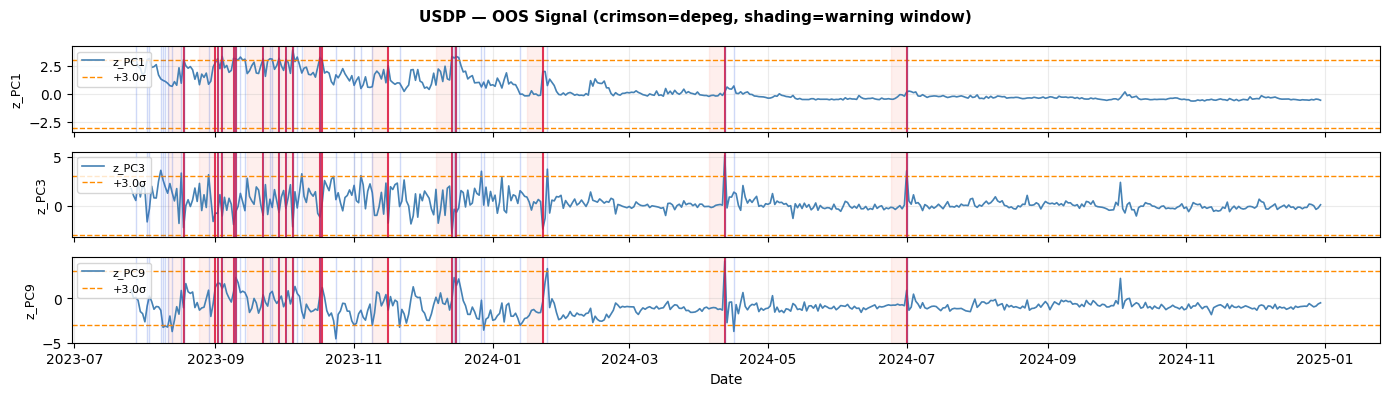

In [23]:
# Plots
for coin, res in results.items():
    plot_signal_timeline(res, coin=coin)

### Loadings

Below we identify the loadings of each selected PCs for all 5 coins.

In [24]:
# Getting the loadings of each selected PCs
for coin, pca_res in [
    ("UST",  ust_pca_result),
    ("USDC", usdc_pca_result),
    ("DAI",  dai_pca_result),
    ("USDT", usdt_pca_result),
    ("USDP", pax_pca_result),
]:
    selected_pcs = PC_SELECTIONS[coin]
    pc_cols = [f"PC{i+1}" for i in selected_pcs]
    
    # Select columns by integer position, rename to PC labels
    loadings = pca_res["loadings"].iloc[:, selected_pcs].copy()
    loadings.columns = pc_cols
    
    print(f"\n{coin} — Loadings for {pc_cols}")
    display(loadings.sort_values(pc_cols[0], key=abs, ascending=False))


UST — Loadings for ['PC4', 'PC6', 'PC10']


,PC4,PC6,PC10
volume_percent_change_30d,0.546512,-0.209997,-0.320556
volume_percent_change_7d,0.446341,0.353289,-0.023447
downward_price_deviation_5d,-0.301950,-0.284180,0.009726
percent_change_24h,-0.274436,-0.084210,-0.267313
realized_daily_volatility,0.262470,0.008052,-0.221534
percent_change_30d,0.260087,-0.230031,0.125079
abs_peg_error,0.231245,-0.135162,0.153762
fed_funds_rate,0.171354,-0.123250,0.058912
downward_price_deviation_30d,-0.157651,0.422199,-0.074537
price_deviation_5d,-0.155248,-0.372115,0.214689



USDC — Loadings for ['PC1', 'PC5', 'PC6']


,PC1,PC5,PC6
circulating_supply_percent_change_30d,0.415532,-0.242247,0.119878
market_cap_percent_change_30d,0.415376,-0.241832,0.120644
market_cap_percent_change_7d,0.415300,-0.019740,0.089683
circulating_supply_percent_change_7d,0.414709,-0.020146,0.087320
market_cap_percent_change_24h,0.290353,0.533999,-0.197411
circulating_supply_percent_change_24h,0.286967,0.531224,-0.207834
fear_greed_index,-0.161681,0.187281,-0.063518
fed_funds_rate,0.161171,-0.144182,0.006374
peg_error,-0.143343,0.038659,0.041270
downward_price_deviation_30d,0.111482,-0.223561,-0.124449



DAI — Loadings for ['PC8', 'PC7', 'PC10']


,PC8,PC7,PC10
fed_funds_rate,0.402884,-0.275987,-0.406088
circulating_supply_percent_change_7d,-0.382024,0.231725,-0.171393
market_cap_percent_change_7d,-0.379520,0.233444,-0.166330
market_cap_percent_change_30d,0.277480,0.094273,0.251069
circulating_supply_percent_change_30d,0.275926,0.094151,0.254077
volume_percent_change_7d,-0.253437,-0.208491,-0.096442
fear_greed_index,0.224464,0.308283,0.199756
circulating_supply_percent_change_24h,0.221283,-0.125409,-0.034342
market_cap_percent_change_24h,0.215419,-0.098161,-0.030564
volume_percent_change_30d,0.202387,0.028298,-0.280537



USDT — Loadings for ['PC4', 'PC7', 'PC8']


,PC4,PC7,PC8
volume_percent_change_7d,0.556714,-0.054313,0.072220
volume_percent_change_24h,0.527072,-0.295883,0.184001
volume_percent_change_30d,0.434630,0.318139,-0.304484
price_deviation_30d,-0.279848,-0.310334,0.105360
circulating_supply_percent_change_30d,0.175540,-0.044905,-0.017596
market_cap_percent_change_30d,0.174543,-0.044215,-0.016640
realized_daily_volatility,0.142768,0.014647,0.627731
downward_price_deviation_30d,-0.118364,0.089581,0.027514
downward_price_deviation_5d,-0.113736,0.221701,0.082504
percent_change_7d,0.098846,-0.108770,-0.131709



USDP — Loadings for ['PC1', 'PC3', 'PC9']


,PC1,PC3,PC9
downward_price_deviation_5d,0.377580,0.019073,0.232056
price_deviation_5d,0.357468,0.127691,0.252270
downward_price_deviation_30d,0.352064,0.181297,-0.269763
price_deviation_30d,0.338006,0.195859,-0.208689
fed_funds_rate,0.334504,0.177682,-0.331270
abs_peg_error,0.303359,-0.012557,0.425960
peg_error,-0.279043,0.435509,0.074584
market_cap_percent_change_30d,0.184110,0.027197,0.025133
circulating_supply_percent_change_30d,0.182119,0.033985,0.022865
market_cap_percent_change_7d,0.163436,0.040521,-0.074969
